# Logistic Regression Fraud Detection Model

## Model Plan

In [1]:
from pathlib import Path
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

PROJECT_ROOT = Path("..").resolve()
DATA_FILE = PROJECT_ROOT / "data" / "processed" / "cleaned_transactions.csv"
MODEL_DIR = PROJECT_ROOT / "models"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
SAMPLE_SIZE = 500_000  # Use the same value as Random Forest for fair comparison.

if not DATA_FILE.exists():
    raise FileNotFoundError("Run src/01_process_data.py first to create cleaned_transactions.csv")

## Load Cleaned Data

In [2]:
use_columns = [
    "id", "date", "amount", "use_chip", "merchant_state", "mcc", "errors", "is_fraud"
]

transactions = pd.read_csv(DATA_FILE, usecols=use_columns)
transactions.shape

(8914963, 8)

In [3]:
transactions["is_fraud"].value_counts(normalize=True).mul(100).round(4).rename("percent")

is_fraud
0    99.8505
1     0.1495
Name: percent, dtype: float64

## Feature Engineering

In [4]:
model_data = transactions.copy()

model_data["date"] = pd.to_datetime(model_data["date"], errors="coerce")
model_data["amount_value"] = pd.to_numeric(
    model_data["amount"].astype(str).str.replace("$", "", regex=False),
    errors="coerce",
)
model_data["abs_amount"] = model_data["amount_value"].abs()
model_data["is_negative_amount"] = (model_data["amount_value"] < 0).astype(int)
model_data["hour"] = model_data["date"].dt.hour
model_data["day_of_week"] = model_data["date"].dt.dayofweek
model_data["month"] = model_data["date"].dt.month
model_data["has_error"] = model_data["errors"].notna().astype(int)

feature_columns = [
    "abs_amount",
    "is_negative_amount",
    "hour",
    "day_of_week",
    "month",
    "use_chip",
    "merchant_state",
    "mcc",
    "has_error",
]

X = model_data[feature_columns]
y = model_data["is_fraud"].astype(int)

pd.DataFrame({"feature": feature_columns})

,feature
0,abs_amount
1,is_negative_amount
2,hour
3,day_of_week
4,month
5,use_chip
6,merchant_state
7,mcc
8,has_error


## Optional Stratified Sampling

In [5]:
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(X):
    sample_fraction = SAMPLE_SIZE / len(X)
    sample_index = (
        pd.DataFrame({"is_fraud": y})
        .groupby("is_fraud", group_keys=False)
        .sample(frac=sample_fraction, random_state=RANDOM_STATE)
        .index
    )
    X_model = X.loc[sample_index]
    y_model = y.loc[sample_index]
else:
    X_model = X
    y_model = y

sample_summary = pd.DataFrame(
    {
        "label": ["Non-fraud", "Fraud"],
        "rows": [int((y_model == 0).sum()), int((y_model == 1).sum())],
        "percent": [round((y_model == 0).mean() * 100, 4), round((y_model == 1).mean() * 100, 4)],
    }
)
sample_summary

,label,rows,percent
0,Non-fraud,499252,99.8504
1,Fraud,748,0.1496


## Train-Test Split


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.25,
    stratify=y_model,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(X_train), len(X_test)],
        "fraud rows": [int(y_train.sum()), int(y_test.sum())],
        "fraud rate (%)": [round(y_train.mean() * 100, 4), round(y_test.mean() * 100, 4)],
    }
)
split_summary

,split,rows,fraud rows,fraud rate (%)
0,train,375000,561,0.1496
1,test,125000,187,0.1496


## Build Logistic Regression Pipeline



In [7]:
numeric_features = ["abs_amount", "is_negative_amount", "hour", "day_of_week", "month", "has_error"]
categorical_features = ["use_chip", "merchant_state", "mcc"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

log_reg_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="lbfgs",
    random_state=RANDOM_STATE,
)

log_reg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", log_reg_model),
    ]
)
log_reg_pipeline

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Train Model

In [8]:
start_time = time.perf_counter()
log_reg_pipeline.fit(X_train, y_train)
training_time_seconds = time.perf_counter() - start_time
round(training_time_seconds, 2)

2.89

## Complexity and Efficiency Notes


In [9]:
encoded_feature_count = len(log_reg_pipeline.named_steps["preprocess"].get_feature_names_out())
complexity_summary = pd.DataFrame(
    {
        "item": [
            "training rows",
            "test rows",
            "input features before encoding",
            "features after one-hot encoding",
            "maximum iterations",
            "solver",
            "training time seconds",
        ],
        "value": [
            len(X_train),
            len(X_test),
            len(feature_columns),
            encoded_feature_count,
            log_reg_pipeline.named_steps["model"].max_iter,
            log_reg_pipeline.named_steps["model"].solver,
            round(training_time_seconds, 2),
        ],
    }
)
complexity_summary

,item,value
0,training rows,375000
1,test rows,125000
2,input features before encoding,9
3,features after one-hot encoding,265
4,maximum iterations,1000
5,solver,lbfgs
6,training time seconds,2.89


## Evaluate Model


In [10]:
y_pred = log_reg_pipeline.predict(X_test)
y_score = log_reg_pipeline.predict_proba(X_test)[:, 1]

metrics_summary = pd.DataFrame(
    {
        "model": ["Logistic Regression"],
        "accuracy": [accuracy_score(y_test, y_pred)],
        "roc_auc": [roc_auc_score(y_test, y_score)],
        "pr_auc": [average_precision_score(y_test, y_score)],
        "training_time_seconds": [training_time_seconds],
    }
)
metrics_summary.round(4)

,model,accuracy,roc_auc,pr_auc,training_time_seconds
0,Logistic Regression,0.9537,0.9712,0.2189,2.8926


In [11]:
print(classification_report(y_test, y_pred, target_names=["Non-fraud", "Fraud"], digits=4))

              precision    recall  f1-score   support

   Non-fraud     0.9999    0.9537    0.9762    124813
       Fraud     0.0286    0.9091    0.0554       187

    accuracy                         0.9537    125000
   macro avg     0.5142    0.9314    0.5158    125000
weighted avg     0.9984    0.9537    0.9749    125000



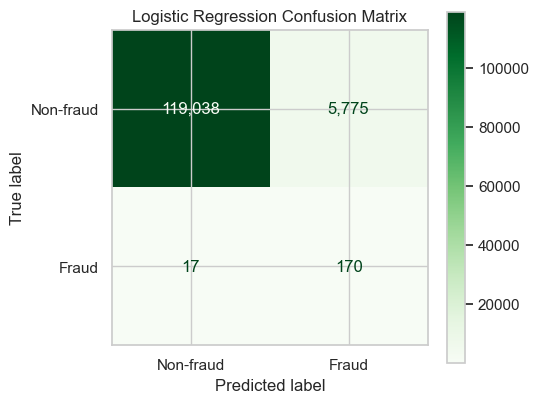

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Non-fraud", "Fraud"],
    cmap="Greens",
    values_format=",d",
    ax=ax,
)
ax.set_title("Logistic Regression Confusion Matrix")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_logistic_regression_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

## Threshold Review

In [13]:
threshold_rows = []
for threshold in [0.10, 0.20, 0.30, 0.40, 0.50]:
    threshold_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, threshold_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "false_positives": fp,
            "false_negatives": fn,
        }
    )

threshold_summary = pd.DataFrame(threshold_rows)
threshold_summary.round(4)

,threshold,precision,recall,f1,false_positives,false_negatives
0,0.1,0.0082,0.9465,0.0163,21412,10
1,0.2,0.0110,0.9465,0.0217,15967,10
2,0.3,0.0145,0.9358,0.0286,11890,12
3,0.4,0.0202,0.9305,0.0395,8455,13
4,0.5,0.0286,0.9091,0.0554,5775,17


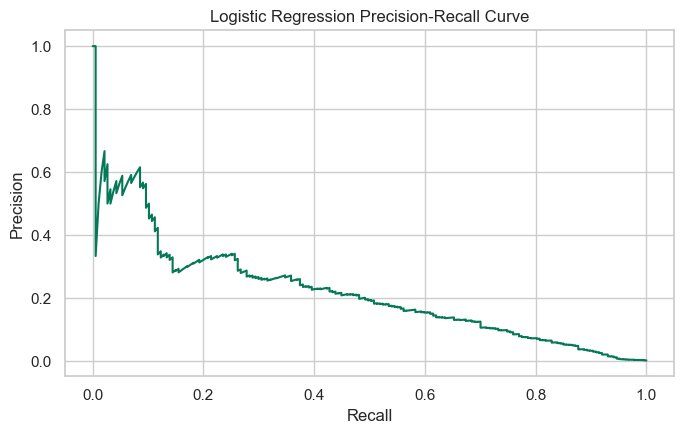

In [14]:
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(recall, precision, color="#047857")
ax.set_title("Logistic Regression Precision-Recall Curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_logistic_regression_precision_recall_curve.png", dpi=160, bbox_inches="tight")
plt.show()

## ROC Curve

In [ ]:
false_positive_rate, true_positive_rate, roc_thresholds = roc_curve(y_test, y_score)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(false_positive_rate, true_positive_rate, color="#047857", label=f"ROC-AUC = {roc_auc_score(y_test, y_score):.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
ax.set_title("Logistic Regression ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate / Recall")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_logistic_regression_roc_curve.png", dpi=160, bbox_inches="tight")
plt.show()

## Coefficient Interpretation

In [86]:
feature_names = log_reg_pipeline.named_steps["preprocess"].get_feature_names_out()
coefficients = log_reg_pipeline.named_steps["model"].coef_[0]

coefficient_table = pd.DataFrame(
    {"feature": feature_names, "coefficient": coefficients}
)
top_positive = coefficient_table.sort_values("coefficient", ascending=False).head(10)
top_negative = coefficient_table.sort_values("coefficient", ascending=True).head(10)

pd.concat(
    [
        top_positive.assign(direction="higher fraud likelihood"),
        top_negative.assign(direction="lower fraud likelihood"),
    ],
    ignore_index=True,
)

,feature,coefficient,direction
0,cat__merchant_state_Italy,14.531253,higher fraud likelihood
1,cat__merchant_state_Haiti,10.693209,higher fraud likelihood
2,cat__mcc_5193,7.576491,higher fraud likelihood
3,cat__mcc_5094,7.510580,higher fraud likelihood
4,cat__mcc_4131,7.460120,higher fraud likelihood
5,cat__mcc_5712,6.593439,higher fraud likelihood
6,cat__mcc_8041,6.556342,higher fraud likelihood
7,cat__merchant_state_DE,5.012526,higher fraud likelihood
8,cat__mcc_5661,4.838332,higher fraud likelihood
9,cat__mcc_7210,4.500607,higher fraud likelihood


## Save Model

In [87]:
model_path = MODEL_DIR / "logistic_regression_fraud_model.joblib"
joblib.dump(log_reg_pipeline, model_path)
model_path

PosixPath('/Users/zichen/Big-Data-Project/models/logistic_regression_fraud_model.joblib')